In [3]:
import torch
from PIL import Image
import open_clip
import matplotlib.py plot as plt

In [6]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

image = preprocess(Image.open("cat.jpg")).unsqueeze(0)
text = tokenizer(["a diagram", "a dog", "a cat"])

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print("Label probs:", text_probs)  # prints: [[0., 0., 1.]]

Label probs: tensor([[6.0926e-06, 1.3223e-05, 9.9998e-01]])


In [15]:
text = tokenizer(["a diagram", "a dog", "a cat","many many many many many many many many many \
                  many many many many many many many many many many many many many many many \
                  many many many many many many many many many many many many many many many \
                  many many many many many many many many many many many many many many many \
                  many many many many many many many many many many many many many many many \
                  many many many many many many many many many many many many many many many \
                  cat"])
print(text.shape)
print(text[-1])

torch.Size([4, 77])
tensor([49406,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,  1346,
         1346,  1346,  1346,  1346,  1346,  1346, 49407])


In [21]:
# Print model structure to txt
with open("model.txt", "w") as f:
    f.write(str(model))

KeyboardInterrupt: 

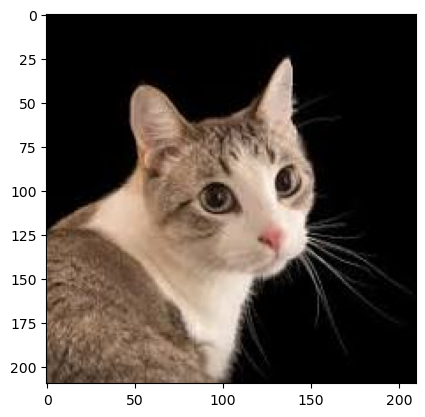

In [24]:
input_img = Image.open("cat.jpg")
plt.imshow(input_img)
image = preprocess(input_img).unsqueeze(0)
# Show image
text_list = ["a diagram", "a dog", "a cat", "a bean plant", "a tree","a sorghum plant"]
text = tokenizer(text_list)

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    
    # Round off the probabilities to 2 decimal places
    text_probs = torch.round(text_probs * 100) / 100
print("Label probs:", text_probs)  # prints: [[0., 0., 1.]]
# print the labels
print(text_list[torch.argmax(text_probs, axis=1)])

In [ ]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

image = preprocess(Image.open("cat.jpg")).unsqueeze(0)
text = tokenizer(["a diagram", "a dog", "a cat"])

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print("Label probs:", text_probs)  # prints: [[0., 0., 1.]]

Label probs: tensor([[6.0926e-06, 1.3223e-05, 9.9998e-01]])


In [1]:
input_img = Image.open("Helios_bean_data_for_Sensing_lab/bean_model_images/helios_simulation0.jpeg")
plt.imshow(input_img)
image = preprocess(input_img).unsqueeze(0)
# Show image
text_list = ["a diagram", "a dog", "a cat", "a bean plant", "a tree", "a sorghum plant"]
text = tokenizer(text_list)

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    
    # Round off the probabilities to 2 decimal places
    text_probs = torch.round(text_probs * 100) / 100
print("Label probs:", text_probs)  # prints: [[0., 0., 1.]]
# print the labels
print(text_list[torch.argmax(text_probs, axis=1)])

NameError: name 'Image' is not defined